# Newly Reported Drug Package Data Exploration 7/27/26 to 8/03/26

This project is an exploratory data analysis project about recently reported product data for drugs in the Medicaid Drug Rebate Program. The data contains information about active outpatient drugs that were reported since the last weekly update of drug products in the MDRP database. I will be reading, understanding, interpreting and answering questions about this data, such as:

* Which companies reported the most newly covered drugs
* What drug types were most commonly reported as of late?
* How many products were removed and reintroduced to market? Are specific drug types added/removed?
* What different information can we understand about these newly reported drugs? How do they differ in dosage, prescription status, or the approval pathways?

In [156]:
import pandas as pd
import matplotlib.pyplot as plt

#importing data
data = pd.read_csv("data/healthcare_data.csv")
df = pd.DataFrame(data)
print(df.tail(10))

      NDC1  NDC2  NDC3            Labeler Name Labeler Status  \
185  83634   653    42            Avenacy Inc.         Active   
186  83634   653    43            Avenacy Inc.         Active   
187  83634   781     1            Avenacy Inc.         Active   
188  83634   781    41            Avenacy Inc.         Active   
189  85477   302    10           Oncora Pharma         Active   
190  85742     4     3  KANCHAN HEALTHCARE INC         Active   
191  85742    13    11  KANCHAN HEALTHCARE INC         Active   
192  85972   101     1    Stellon Biotech Inc.         Active   
193  85972   102     1    Stellon Biotech Inc.         Active   
194  85972   103     1    Stellon Biotech Inc.         Active   

                                              FDA Name  COD Status  \
185               LIDOCAINE HCL INJ, USP 50MG/5ML VIAL           1   
186             LIDOCAINE HCL INJ, USP 300MG/30ML VIAL           1   
187  DIPHENHYDRAMINE HYDROCHLORIDE INJ, USP 50MG/ML...           1   
188 

First step is understanding what all these columns mean:

| Column Name | Description |
|---|---|
| **NDC1** | NDC labeler segment; identifies the manufacturer, distributor, or other labeling organization. |
| **NDC2** | NDC product segment; identifies a particular strength, dosage form, and formulation. |
| **NDC3** | NDC package segment; identifies the package size and configuration. |
| **Labeler Name** | Name of the organization responsible for labeling the product. |
| **Labeler Status** | Indicates whether the labeler participates in the Medicaid Drug Rebate Program (MDRP). |
| **FDA Name** | Product name associated with the FDA listing, which may include the strength, dosage form, or package information. |
| **COD Status** | Covered Outpatient Drug status; identifies the regulatory pathway or statutory basis under which the product qualifies. |
| **FDA Application Number** | FDA application number under which the product is marketed. |
| **Drug Category** | Indicates whether the product is single-source, innovator multiple-source, or non-innovator multiple-source. |
| **Drug Type** | Indicates whether the product is prescription or over-the-counter (OTC). |
| **Line Extension** | Indicates whether the product is a line extension of another product for MDRP purposes. |
| **FDA Approval Date** | Date the NDA, ANDA, or BLA was approved. For products not requiring FDA approval, CMS applies special date rules. |
| **Market Date** | Earliest date the drug was marketed under its application. |
| **Unit Type** | Smallest unit normally used to dispense the product and calculate its rebate. |
| **Unit Per Package Size** | Number of units contained in the package. |
| **Therapeutic Equivalent Code** | FDA Orange Book code describing the product's therapeutic-equivalence or bioequivalence status. |
| **5i Indicator** | Indicates whether the drug is inhaled, infused, instilled, implanted, or injected, which is relevant to Medicaid Average Manufacturer Price (AMP) calculations. |
| **Purchased Product Date** | Date associated with CMS's purchased-product reporting provisions, primarily relevant to eligible 5i drugs. A blank value generally means it was not applicable or was not reported. |
| **Coverage Effective Date** | Date the product became effective for coverage under the MDRP. |
| **Drug Termination Date** | Date the product was withdrawn from the market or its last lot expired. A blank value means no termination date is currently recorded. |
| **Drug Reactivation Date** | Date a previously terminated product was reintroduced. |
| **Date Reported to CMS** | Date the product information was submitted to or entered into CMS's reporting system. |

It's also important to understand encoded values for certain columns that use symbols:

### Drug Category

| Value | Meaning |
|:---|:---|
| **S** | Single-source drug |
| **I** | Innovator multiple-source drug |
| **N** | Non-innovator multiple-source drug |

### Drug Type

| Value | Meaning |
|---|---|
| **1** | Prescription drug |
| **2** | OTC drug |

### 

### COD Status

*pandas dataframe removed the leading 0*
| Code | Meaning |
| ---|---|
| **01** | Abbreviated New Drug Application - ANDA |
| **02** | Biologics License Application - BLA |
| **03** | New Drug Application--NDA |
| **04** | NDA authorized generic |
| **05** | DESI 5 product LTE/IRS drug for all indications - Ineligible for MDPR|
| **06** | DESI 6 product TE/IRS drug withdrawn from market - Ineligible for MDPR|
| **07** | Prescription pre-natal vitamin or fluoride |
| **08** | Other prescription dietary supplement, vitamin, or mineral |
| **09** | Tentative OTC monograph |
| **10** | Final OTC monograph |
| **11** | Unapproved - drug shortage |
| **12** | Unapproved drug per 1927(k)(2)(A)(ii)
| **13** | Unappproved drug per 1927(k)(2)(A)(iii)

### Unit Type

| Value | Meaning |
|:---|:---|
|**TAB**|Tablet|
|**CAP**|Capsule|
|**ML**|Milliliter|
|**GM**|Gram|
|**EA**|Each|
|**SUP**|Suppository|
|**TDP**|Transdermal patch|
|**AHF**|Injectable anti-hemophilic factor|
|**MCI**|Millicurie|
|**UCI**|Microcurie|

### Common Therapeutic-Equivalence Codes

|Value|Meaning|
|---|---|
|**AA**|Conventional dosage form with no identified bioequivalence problem|
|**AB**|Meets bioequivlance requirements|
|**AN**|Solution or powder for aerosolization|
|**AP**|Injectable aqueous solution|
|**AT**|Topical product|
|**BC**|Extended release dosage|
|**NR**| Not rated|

## Data Cleaning for Exploratory Data Analysis

The data needs to be cleaned and reformatted in preparation of analysis.

In [173]:
df["NDC11"] = (
    df["NDC1"].astype(str).str.zfill(5)
    + df["NDC2"].astype(str).str.zfill(4)
    + df["NDC3"].astype(str).str.zfill(2)
)
df["NDC9"] = (
    df["NDC1"].astype(str).str.zfill(5) 
    + df["NDC2"].astype(str).str.zfill(4)
)
print(df["NDC11"],df["NDC9"])   

0      00053011011
1      00054082158
2      00054096213
3      00054096313
4      00054096413
          ...     
190    85742000403
191    85742001311
192    85972010101
193    85972010201
194    85972010301
Name: NDC11, Length: 195, dtype: object 0      000530110
1      000540821
2      000540962
3      000540963
4      000540964
         ...    
190    857420004
191    857420013
192    859720101
193    859720102
194    859720103
Name: NDC9, Length: 195, dtype: object


**NDC 11** is the standardized 10 or 11 digit number to report drugs. It adds the NDC1,NDC2,and NDC3 numbers together in a 4-4-2, 5-3-2, or 5-4-1 orientation. The only difference between the 11 and 10 digit iterations is a leading 0 on the ND1 number. 

Next step is isolating unique drugs to find out which manufacturer, labeler, or distributor reports the most drugs and figuring out which manufacturers provide the most packages, uniqueness notwithstanding.   

In [176]:
ndc_df = df[
[
    "NDC1",
    "NDC2",
    "NDC3",
    "Labeler Name",
    "FDA Name",
    "Drug Category",
    "Drug Type",
    "COD Status",
    "5i Indicator",
    "Therapeutic Equivalent Code",
    "Unit Type",
    "Unit Per Package Size",
    "NDC9",
    "NDC11",
    "Coverage Effective Date",
    "Date Reported to CMS"
]
].copy()







ndc_df["NDC9"] = (
    df["NDC1"].astype("string").str.zfill(5)
    + df["NDC2"].astype("string").str.zfill(4)
)

ndc_df["NDC11"] = (
    df["NDC9"]
    + df["NDC3"].astype("string").str.zfill(2)
)
#standardizing label names

ndc_df["Labeler Name Standardized"] = (
    ndc_df["Labeler Name"]
    .str.strip()
    .str.upper()
)
unique_products = (
    ndc_df.drop_duplicates(subset="NDC9")
          .reset_index(drop=True)
          .copy()
)

labeler_summary = (
    df.groupby("Labeler Name")
    .agg(
        unique_products=("NDC9","nunique"),
        package_ndcs=("NDC11","nunique")
    )
    .assign(
        packages_per_product=lambda x: x["package_ndcs"] / x["unique_products"]
    )
    .sort_values("unique_products",ascending=False)
    .reset_index()
)
labeler_summary


,Labeler Name,unique_products,package_ndcs,packages_per_product
0,CHARTWELL RX LLC,14,14,1.000000
1,"NOVADOZ PHARMACEUTICALS, LLC",10,11,1.100000
2,Caplin Steriles Limited,8,8,1.000000
3,Umedica Laboratories USA Inc.,7,10,1.428571
4,L. PERRIGO COMPANY,6,7,1.166667
5,HIKMA PHARMACEUTICALS USA INC.,6,7,1.166667
6,"AUROBINDO PHARMA USA, INC.",6,6,1.000000
7,"Sentiss Pharmaceuticals, LLC",5,6,1.200000
8,"ACELLA PHARMACEUTICALS, LLC",5,5,1.000000
9,"ANI PHARMACEUTICALS, INC.",5,5,1.000000


## Visualization and Analysis

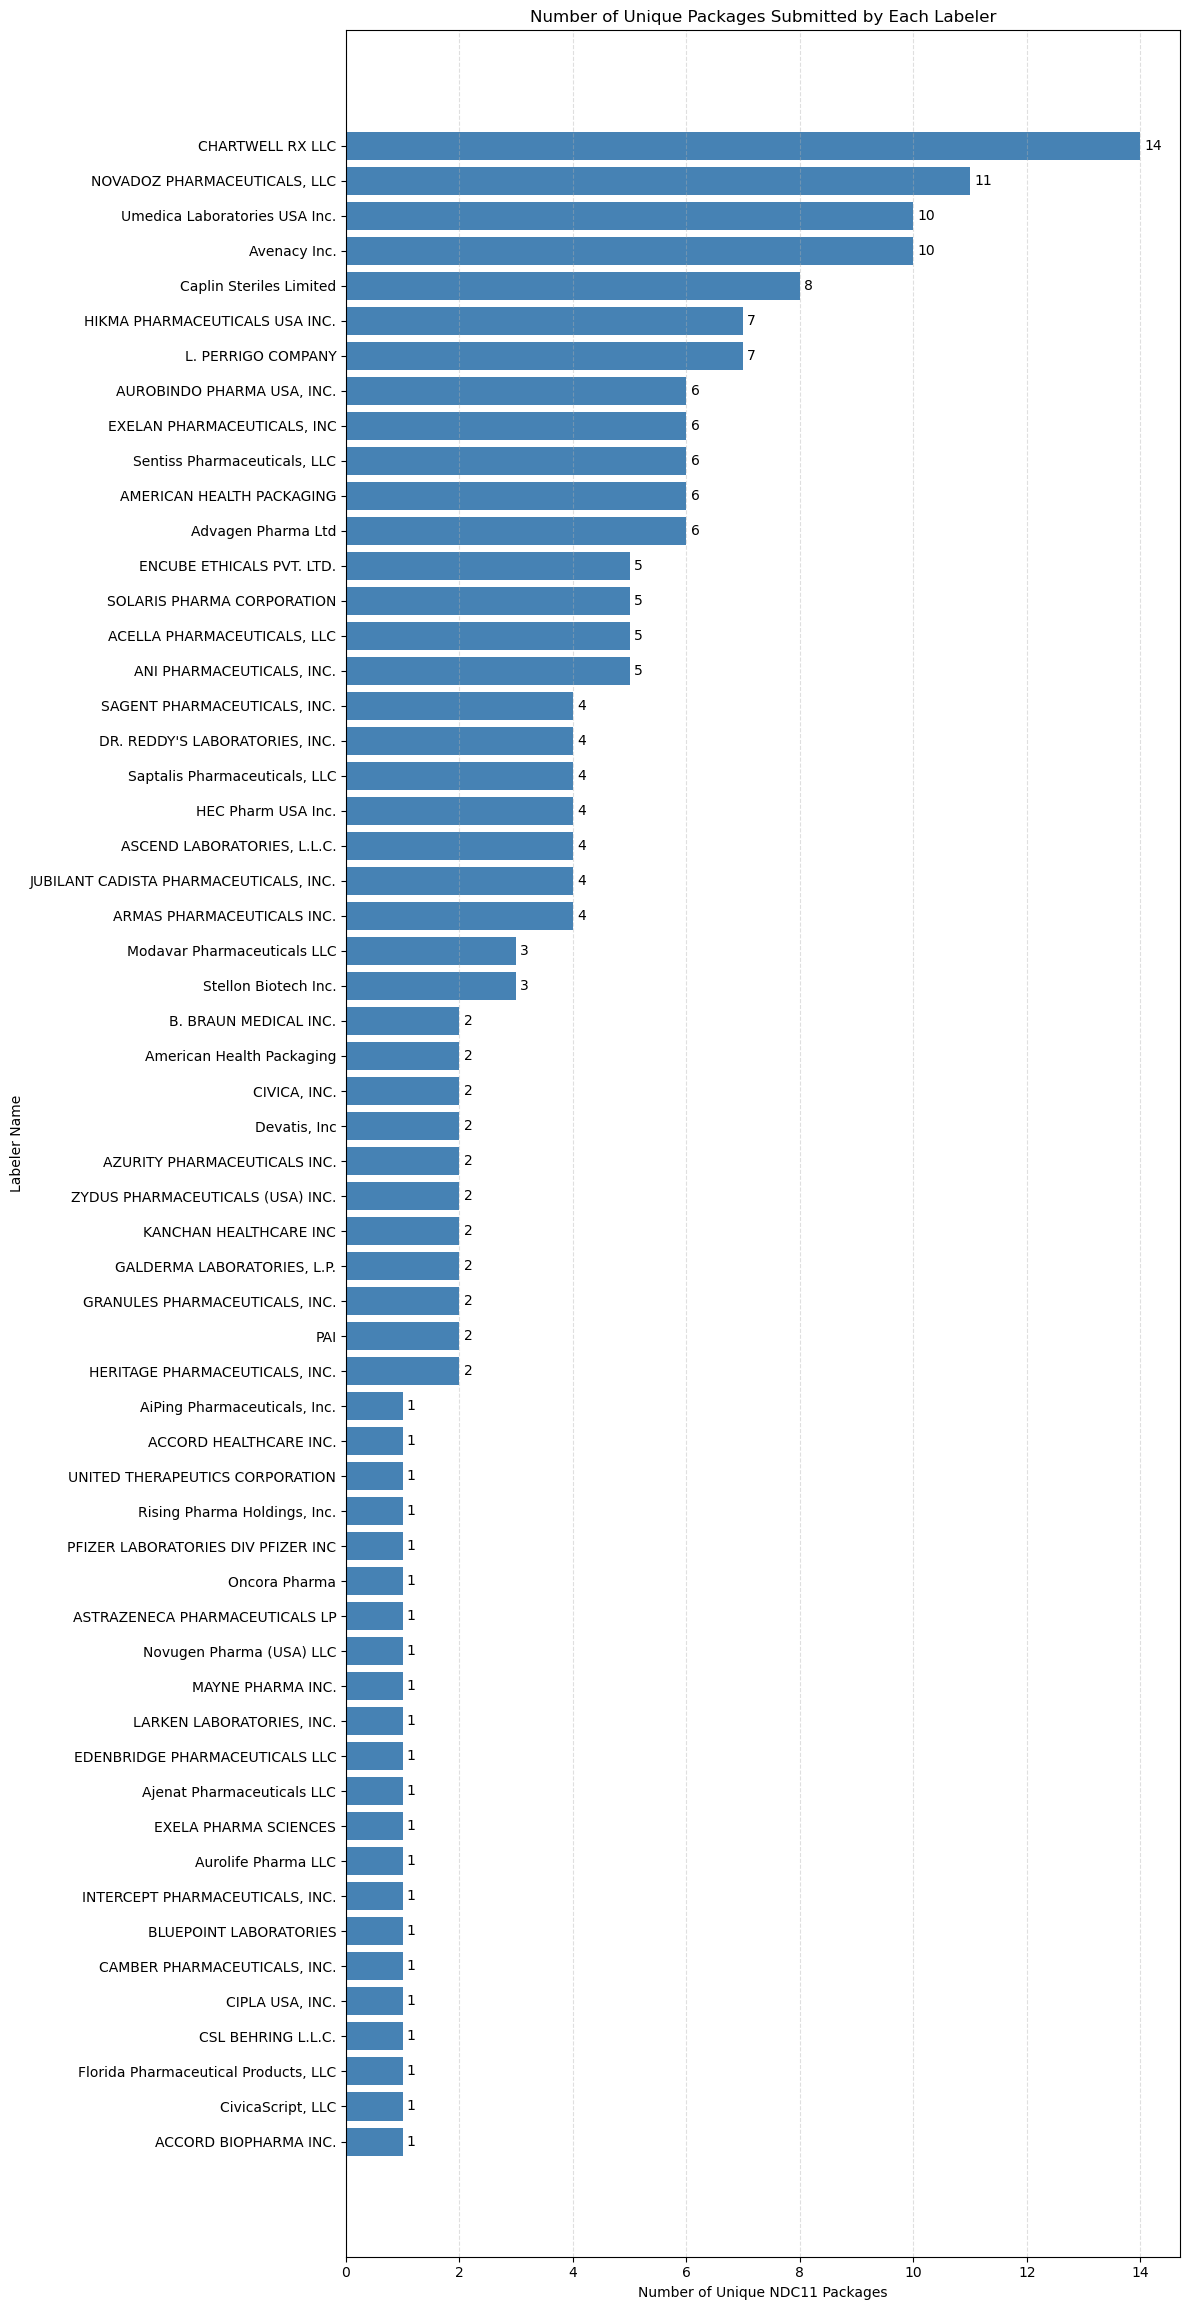

In [178]:
import matplotlib.pyplot as plt

packages_by_labeler = (
    ndc_df.groupby("Labeler Name")["NDC11"]
          .nunique()
          .sort_values()
)

fig, ax = plt.subplots(
    figsize=(12, max(8, len(packages_by_labeler) * 0.4))
)

bars = ax.barh(
    packages_by_labeler.index,
    packages_by_labeler.values,
    color="steelblue"
)

# Display each package count beside its bar
ax.bar_label(bars, padding=3)

ax.set_title("Number of Unique Packages Submitted by Each Labeler")
ax.set_xlabel("Number of Unique NDC11 Packages")
ax.set_ylabel("Labeler Name")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [179]:
companies_with_one = (packages_by_labeler == 1).sum()
company_with_most = (packages_by_labeler.idxmax())
print(packages_by_labeler.sum())
max_packages = (packages_by_labeler.max())
print(f"The amount of companies that sumitted one package is: {companies_with_one}")
print(f"The company with the most packages submitted is {company_with_most} with {max_packages}")
packages_by_labeler.describe()

195
The amount of companies that sumitted one package is: 22
The company with the most packages submitted is CHARTWELL RX LLC with 14


count    58.000000
mean      3.362069
std       2.959957
min       1.000000
25%       1.000000
50%       2.000000
75%       5.000000
max      14.000000
Name: NDC11, dtype: float64

There are a few insights we can gain from this number of NDC11 packages submitted from each labeler:

+ 1 package submitted is the most frequent amount, with 22 companies submitting that amount.
+ 58 total companies submitted at least one package during this time period.
+ The company with the most submitted packages was Chartwell RX LLC with 14.
+ The average amount of packages submitted was 3.4, but this is heavily left skewed with so many labelers only submitting 1.
+ The total amount of packages submitted during this timeframe was 195. 

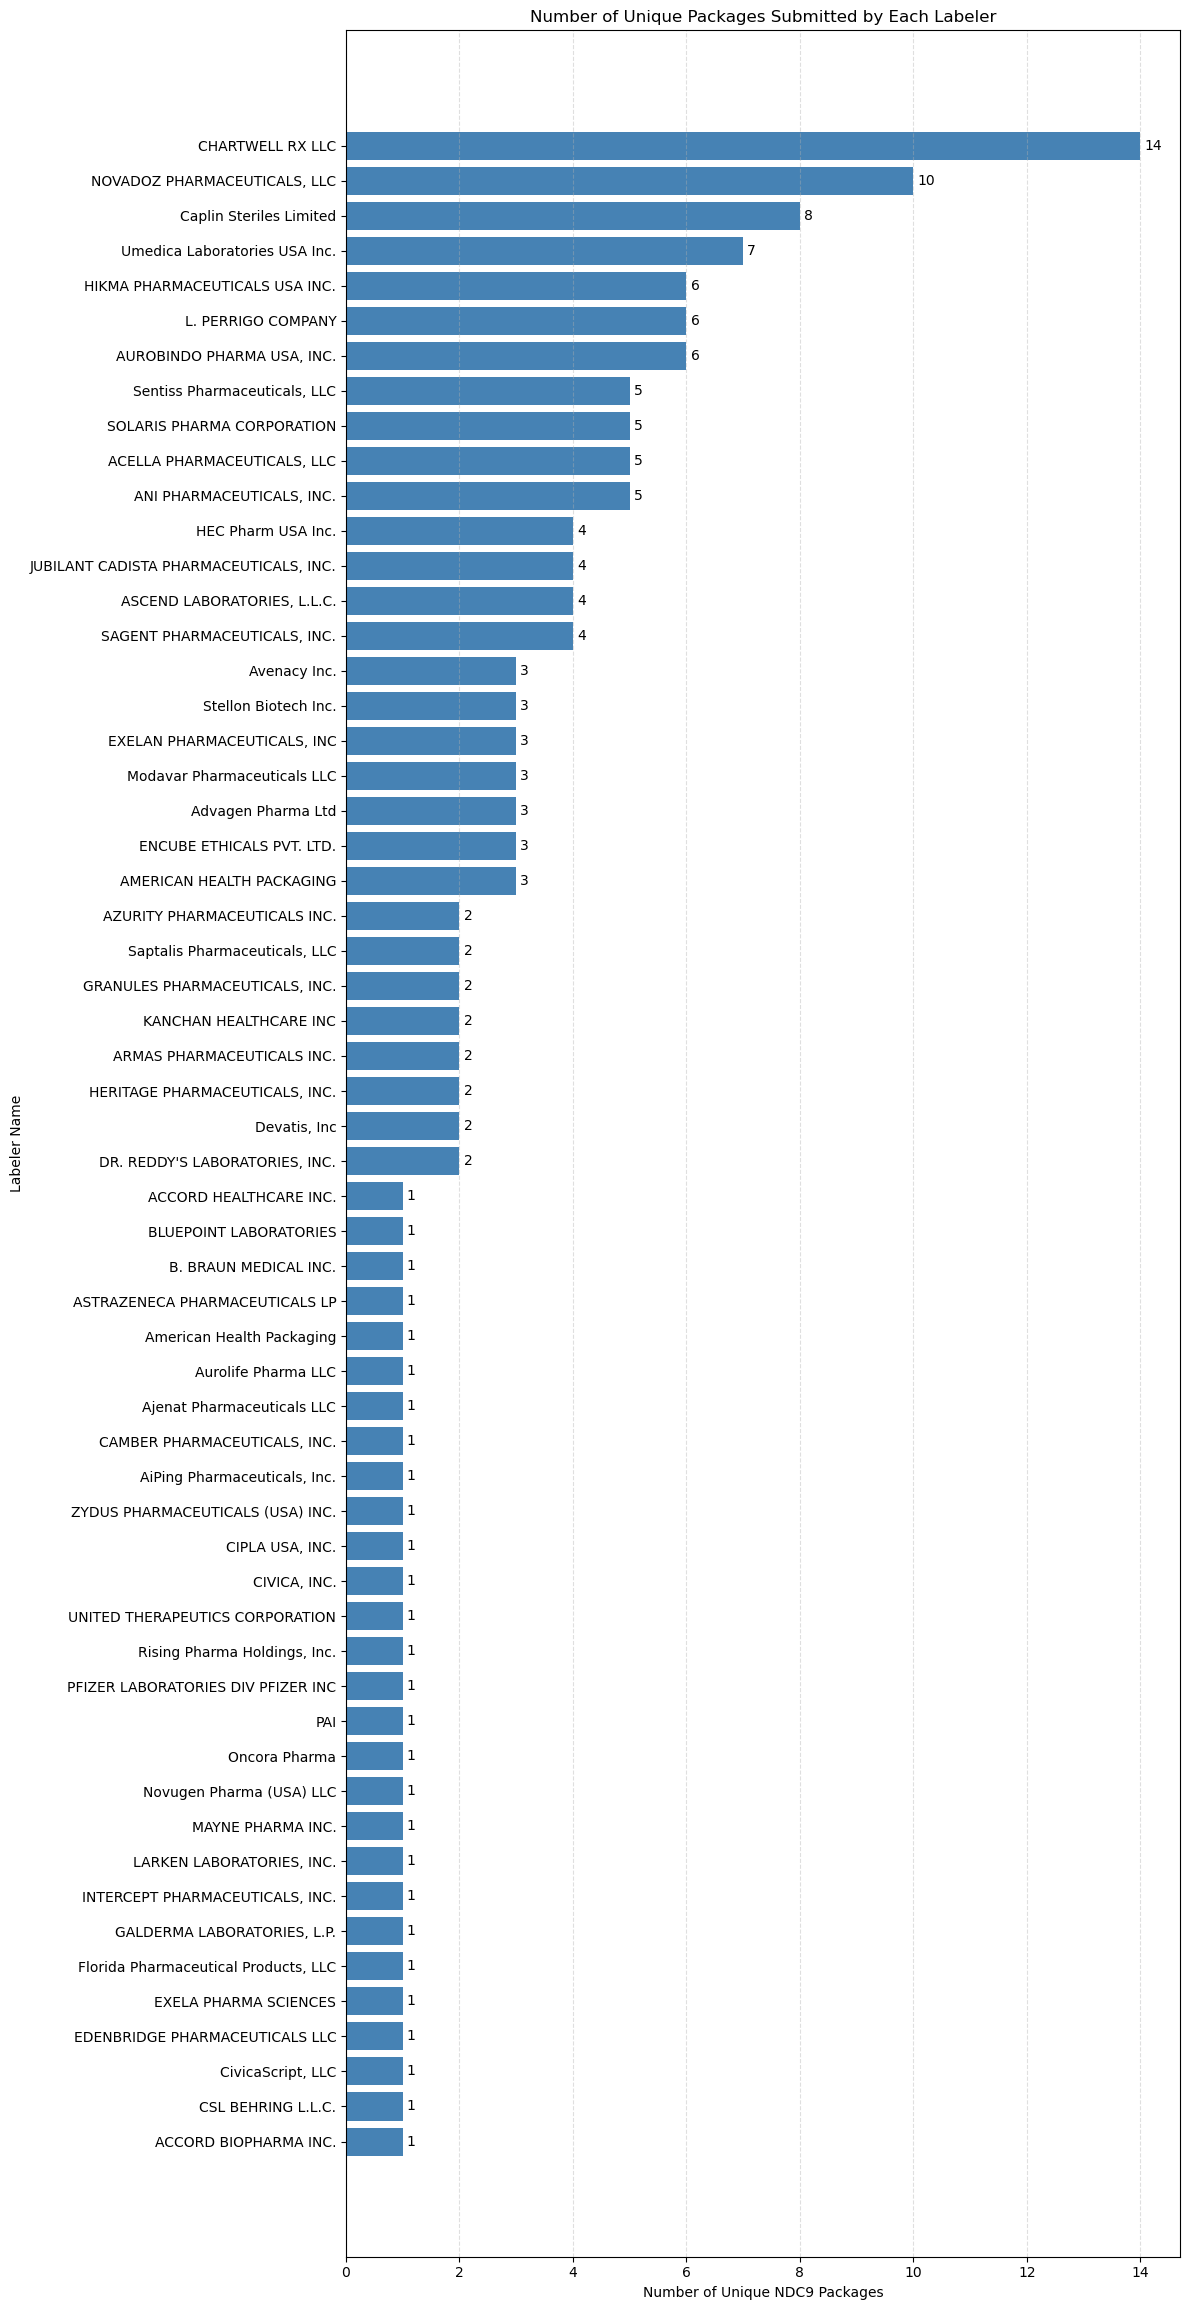

In [181]:
packages_by_labeler = (
    ndc_df.groupby("Labeler Name")["NDC9"]
          .nunique()
          .sort_values()
)

fig, ax = plt.subplots(
    figsize=(12, max(8, len(packages_by_labeler) * 0.4))
)

bars = ax.barh(
    packages_by_labeler.index,
    packages_by_labeler.values,
    color="steelblue"
)

# Display each package count beside its bar
ax.bar_label(bars, padding=3)

ax.set_title("Number of Unique Packages Submitted by Each Labeler")
ax.set_xlabel("Number of Unique NDC9 Packages")
ax.set_ylabel("Labeler Name")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [182]:
products_by_labeler = (
    ndc_df.groupby("Labeler Name")["NDC9"]
          .nunique()
          .sort_values()
)

companies_with_one_product = (products_by_labeler == 1).sum()
company_with_most_products = products_by_labeler.idxmax()
max_products = products_by_labeler.max()

print(
    f"The number of labelers that submitted one unique product is: "
    f"{companies_with_one_product}"
)

print(
    f"The labeler with the most unique products submitted is "
    f"{company_with_most_products}, with {max_products} products."
)

products_by_labeler.describe()

The number of labelers that submitted one unique product is: 28
The labeler with the most unique products submitted is CHARTWELL RX LLC, with 14 products.


count    58.000000
mean      2.724138
std       2.560106
min       1.000000
25%       1.000000
50%       2.000000
75%       3.750000
max      14.000000
Name: NDC9, dtype: float64

Looking at the NDC9 label data is a little different:

+ The total number of products submitted by the labelers are 158, this implies that there are 37 less product records than package records. 
+ The mean decreases relative to the NDC11 label data. The value is 2.72. This makes intuitive sense because the amount of labelers remain the same, with NDC9 only being product records. 
+ The max of 14 that Chartwell Rx LLC submitted was the same, this means that they submitted 14 distinct products, with only one package type. 
+ 28 labelers submitted only one package.
  

In [184]:
#Which products have multiple package configs

packages_per_product = (
    ndc_df.groupby(["Labeler Name", "NDC9"])["NDC11"].nunique().sort_values(ascending=False))

products_with_multiple_packages = packages_per_product[
    packages_per_product > 1
]

print("Products with multiple packages:", len(products_with_multiple_packages))
print(products_with_multiple_packages)

names = ndc_df["Labeler Name"].isna().sum()
#print(f"The amount of missing labeler names is: {names}")

Products with multiple packages: 33
Labeler Name                      NDC9     
Avenacy Inc.                      836340653    6
EXELAN PHARMACEUTICALS, INC       762820795    2
                                  762820794    2
Advagen Pharma Ltd                728880501    2
American Health Packaging         680020105    2
Avenacy Inc.                      836340403    2
                                  836340781    2
B. BRAUN MEDICAL INC.             002648200    2
CIVICA, INC.                      725720356    2
DR. REDDY'S LABORATORIES, INC.    435980924    2
                                  435980925    2
ENCUBE ETHICALS PVT. LTD.         219220091    2
                                  219220093    2
EXELAN PHARMACEUTICALS, INC       762820796    2
Advagen Pharma Ltd                728880499    2
GALDERMA LABORATORIES, L.P.       002994908    2
HIKMA PHARMACEUTICALS USA INC.    001439476    2
L. PERRIGO COMPANY                001130443    2
NOVADOZ PHARMACEUTICALS, LLC      7220

## Analysis

+ Avenacy Inc. was the labeler with the most package configurations with 6, they were also the only labeler who had more than 2 package configurations for their product. 

In [187]:
# Packages per product/ each labeler 
labeler_summary = (
    ndc_df.groupby("Labeler Name")
          .agg(
              unique_products=("NDC9", "nunique"),
              unique_packages=("NDC11", "nunique")
          )
)

labeler_summary["packages_per_product"] = (
    labeler_summary["unique_packages"]
    / labeler_summary["unique_products"]
)

labeler_summary.sort_values(
    "packages_per_product",
    ascending=False
)

,unique_products,unique_packages,packages_per_product
Labeler Name,,,
Avenacy Inc.,3,10,3.333333
ZYDUS PHARMACEUTICALS (USA) INC.,1,2,2.000000
Advagen Pharma Ltd,3,6,2.000000
"GALDERMA LABORATORIES, L.P.",1,2,2.000000
"EXELAN PHARMACEUTICALS, INC",3,6,2.000000
"DR. REDDY'S LABORATORIES, INC.",2,4,2.000000
"CIVICA, INC.",1,2,2.000000
B. BRAUN MEDICAL INC.,1,2,2.000000
American Health Packaging,1,2,2.000000


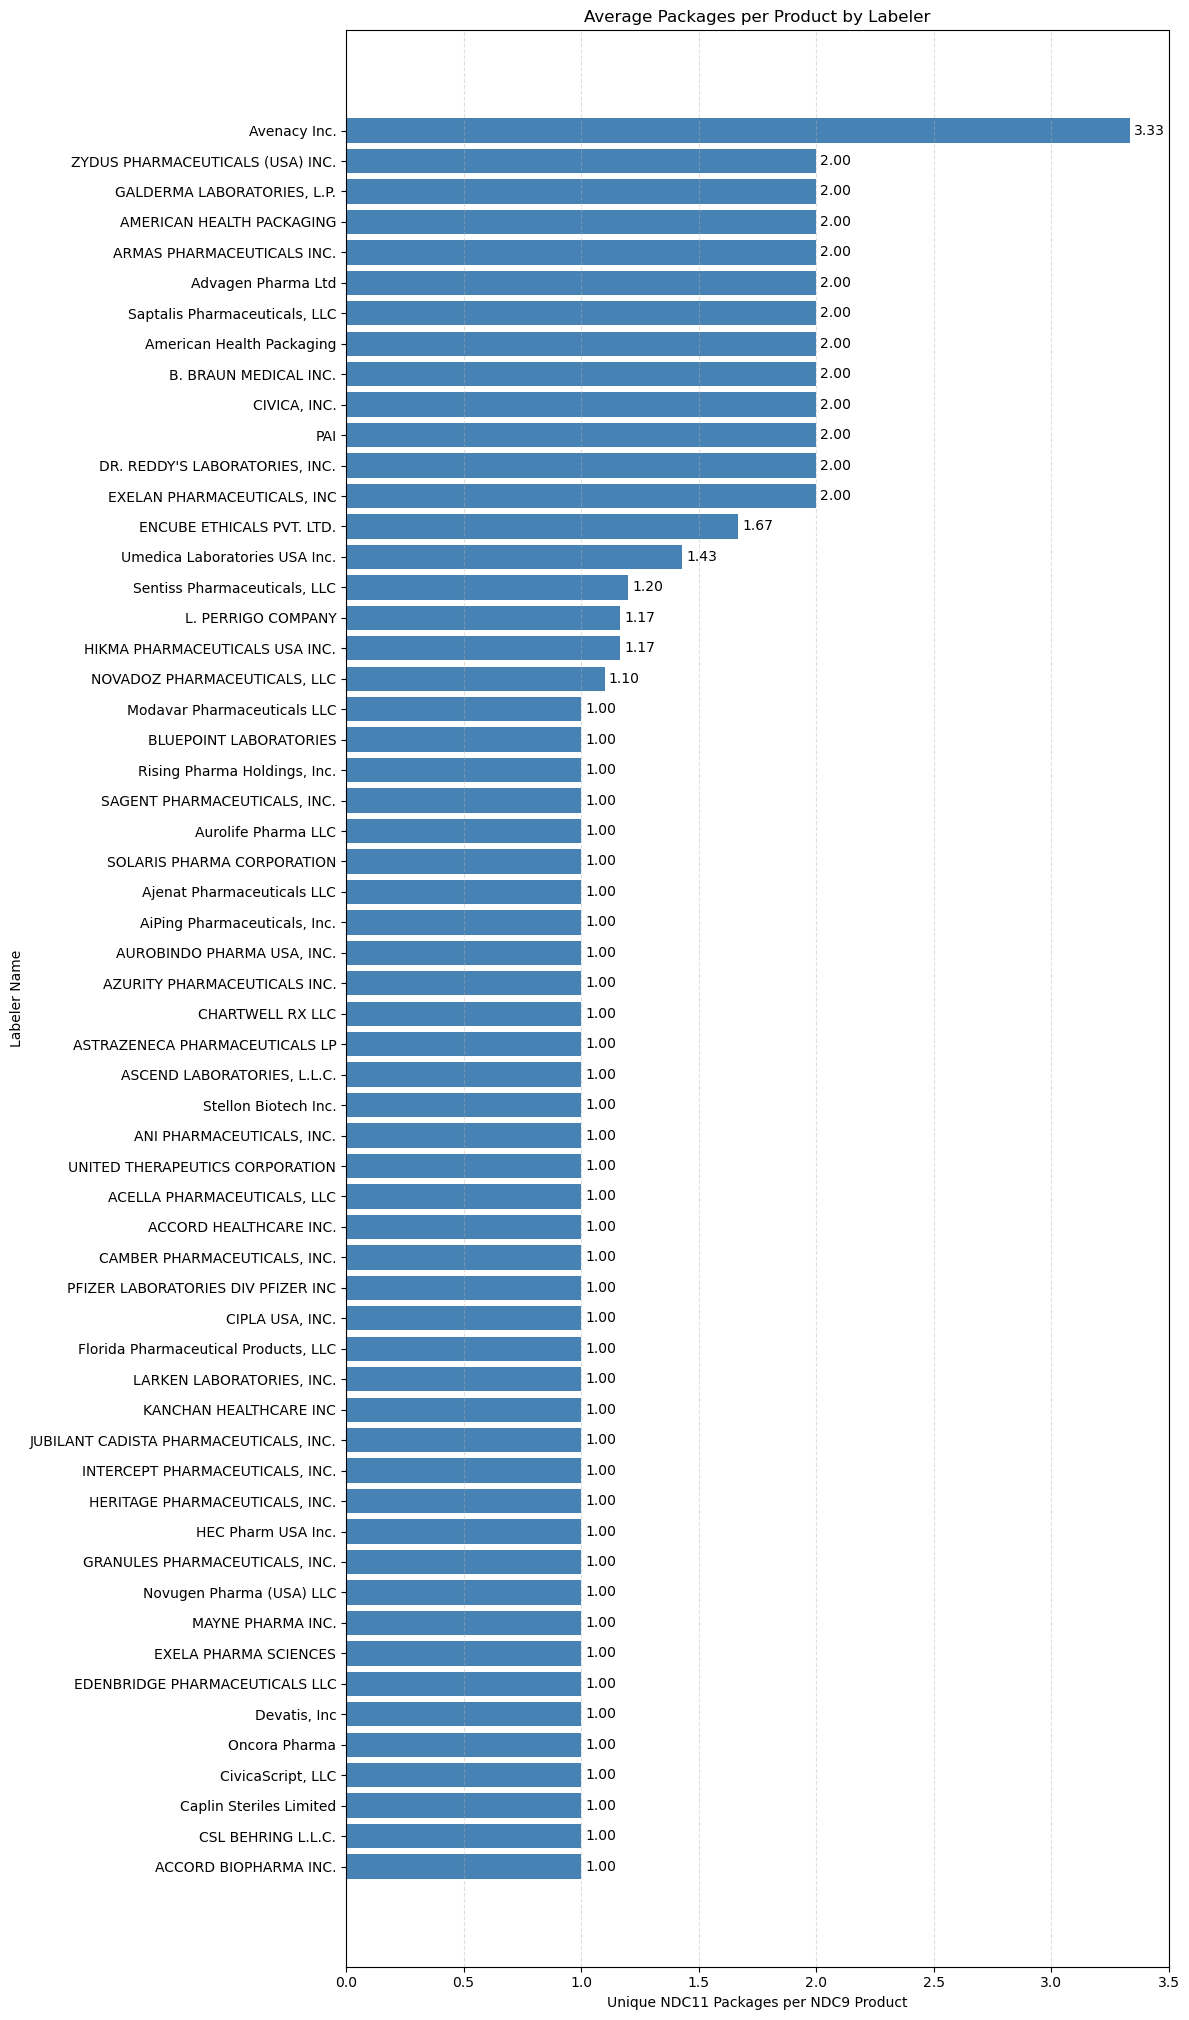

In [188]:
plot_data = labeler_summary.sort_values("packages_per_product")

fig, ax = plt.subplots(
    figsize=(12, max(8, len(plot_data) * 0.35))
)

bars = ax.barh(
    plot_data.index,
    plot_data["packages_per_product"],
    color="steelblue"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value in plot_data["packages_per_product"]
    ],
    padding=3
)

ax.set_title("Average Packages per Product by Labeler")
ax.set_xlabel("Unique NDC11 Packages per NDC9 Product")
ax.set_ylabel("Labeler Name")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [189]:
# What percentage of products came from largest labeler
top_5_share = (
    products_by_labeler.nlargest(5).sum()
    / products_by_labeler.sum()
    * 100
)

print(f"The top five labelers reported {top_5_share:.1f}% of all products.")
# distributions

The top five labelers reported 28.5% of all products.


### Analysis

This could be interesting to look at as a point where irregularities could be investigated further. If the % share of reported products an arbitrary top percentage of these labelers usually have, a moving average of sorts could be discovered, it could be used it to flag irregularities in the distribution. We could even expand this further and look at it at all percentiles. 

In [192]:
#Product characteristics

unique_products = ndc_df.drop_duplicates("NDC9").reset_index(drop=True)
ndc_11_prods = ndc_df.drop_duplicates("NDC11")

#unique_products["Drug Category"].value_counts()
unique_products["Drug Type"].value_counts()
#unique_products["COD Status"].value_counts()
#unique_products["5i Indicator"].value_counts()
#unique_products["Therapeutic Equivalent Code"].value_counts()

#ndc_11_prods["Drug Category"].value_counts()
#ndc_11_prods["Drug Type"].value_counts()
#ndc_11_prods["COD Status"].value_counts()
#ndc_11_prods["5i Indicator"].value_counts()
#ndc_11_prods["Therapeutic Equivalent Code"].value_counts()

Drug Type
1    143
2     15
Name: count, dtype: int64

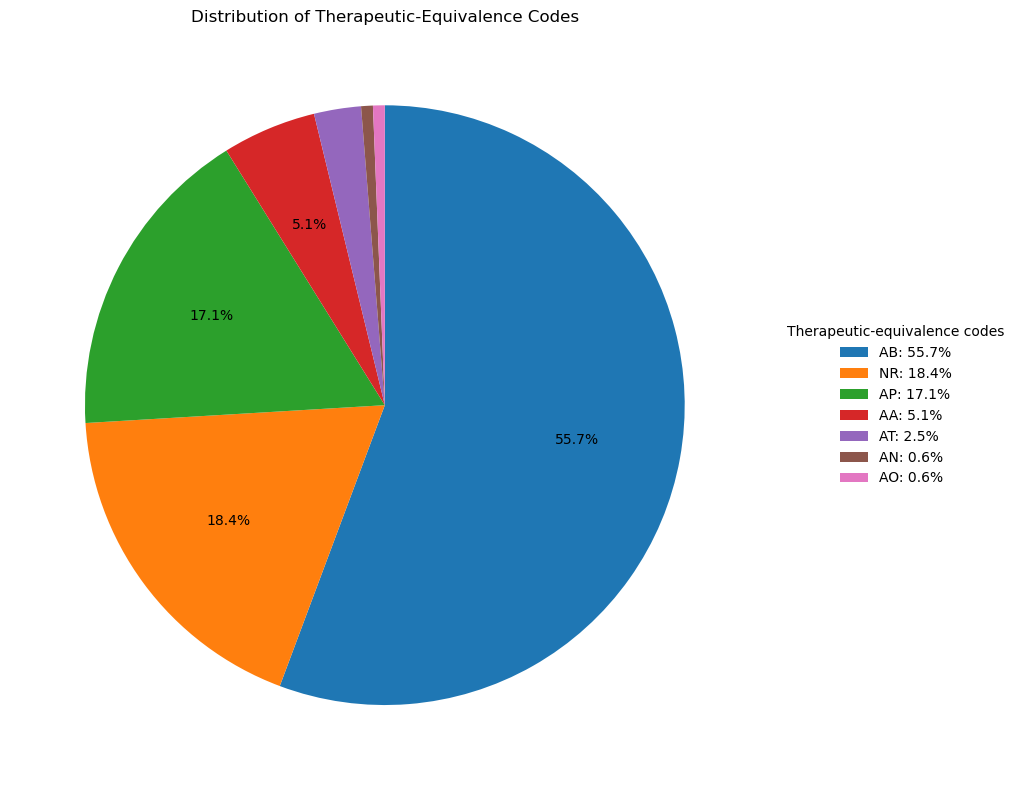

In [193]:
import matplotlib.pyplot as plt

codes_for_prods = (
    ndc_df.groupby("Therapeutic Equivalent Code")["NDC9"]
          .nunique()
          .sort_values(ascending=False)
)

codes_sorted = codes_for_prods.sort_values(ascending=False)
percentages = codes_sorted / codes_sorted.sum() * 100

fig, ax = plt.subplots(figsize=(11, 8))

wedges, _, _ = ax.pie(
    codes_sorted.values,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    startangle=90,
    counterclock=False,
    pctdistance=0.65
)

legend_labels = [
    f"{code}: {percentage:.1f}%"
    for code, percentage in percentages.items()
]

ax.legend(
    wedges,
    legend_labels,
    title="Therapeutic-equivalence codes",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.set_title("Distribution of Therapeutic-Equivalence Codes")

plt.tight_layout()
plt.show()

In [194]:
total = codes_for_prods.sum()

for code,count in codes_for_prods.sort_values(ascending=False).items():
    ratio = count / total
    print(f"{code}:{ratio:.2%}")

AB:55.70%
NR:18.35%
AP:17.09%
AA:5.06%
AT:2.53%
AN:0.63%
AO:0.63%


### Analysis 

The most common equivalance code was AB, which means they meet equivalence requirements. The second most common was Not Rated. The third most common was AP, an injectable aqueous solution. The fourth, fifth, sixth, and seventh were AA (conventional dosage with no bioequivalence problem), AT (topical product), AO (injectable oil solution), and AN (solutions or powder for aerosolization) respectively. 

Not rated does not necessarily mean that the product is unsafe. 

In [197]:
unique_packages = ndc_df.drop_duplicates("NDC11")

unique_packages.groupby("Unit Type")[
    "Unit Per Package Size"
].describe()

,count,mean,std,min,25%,50%,75%,max
Unit Type,,,,,,,,
CAP,17.0,65.588235,48.588912,1.0,1.00,90.0,100.000,120.0
EA,6.0,1.000000,0.000000,1.0,1.00,1.0,1.000,1.0
GM,14.0,26.285714,17.385576,3.5,14.25,23.0,39.375,60.0
ML,62.0,102.316129,192.089629,0.3,5.00,22.5,90.000,1000.0
TAB,95.0,119.905263,230.985496,1.0,30.00,60.0,95.000,1000.0
TDP,1.0,1.000000,NaN,1.0,1.00,1.0,1.000,1.0


### Visualization

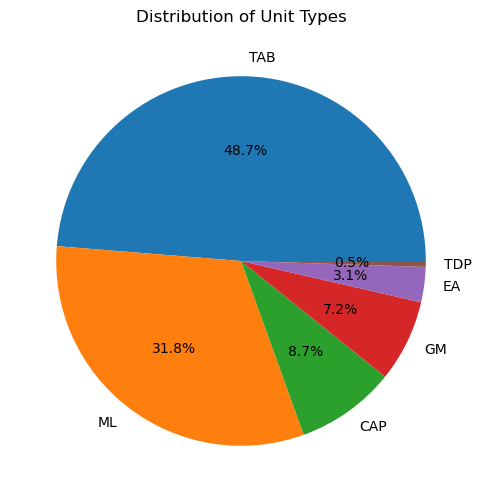

In [199]:
#print(len(unique_packages["Unit Type"]))

unit_counts = unique_packages["Unit Type"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    unit_counts.values,
    labels=unit_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Unit Types")
plt.show()

### Analysis

- The most common package unit was tablets, followed by milliliters, capsules, grams, each, and transdermal patch respectively.
- This would track with the expectation that transdermal patches would be quite uncommon, not many drugs are administered this way.
- Unit types could also be a potential area to model and investigate if new reports deviate vastly from historical averages.
- The widest unit range belongs to the milliliter unit, with 0.3ml being the smallest and 1000ml being the largest.
- ML and TAB both have means that exceed their medians significantly, suggesting a heavy right-skew due to the largest packages.
- Despite having a very slightly larger range, ML packages have a smaller deviation than TAB packages.

In [202]:

y_count = (unique_products["5i Indicator"]  == "Y").sum()
total = len(unique_products)

y_proportion = (y_count / total)

print(f" Y count: {y_count} out of {total}")
print (f" The proportion of Y in the set is: {y_proportion:.2%}")

 Y count: 35 out of 158
 The proportion of Y in the set is: 22.15%


### Analysis

+ This means that 22.15% of these newly reported drugs are classified as 5i products. The definition of the 5i classification are drugs that are inhaled, infused, injected, implanted, or instilled. The manufacturer must determine if the drug is not generally dispensible to commercial entities.
+ Some 5i classified drugs may require specialized administration settings or trained personnel, but the dataset does not identify where they are sold or administered.

In [205]:
coverage_dates = unique_products["Coverage Effective Date"]
print(coverage_dates.value_counts(dropna=True).head(10))

Coverage Effective Date
06/22/2026    13
06/16/2026    10
06/01/2026     7
06/25/2026     7
06/03/2026     7
06/09/2026     7
06/15/2026     6
06/17/2026     5
06/08/2026     5
07/28/2026     4
Name: count, dtype: int64


+ The first nine most frequent coverage dates were a date in June, the month before this dataset. This could suggest most newly reported products have recent coverage dates. This cant be verified with only one week of data though. 

In [207]:
unique_products = unique_products.copy()

unique_products["Date Reported to CMS"] = pd.to_datetime(
    unique_products["Date Reported to CMS"],
    format="%m/%d/%Y",
    errors="coerce"
)

unique_products["Coverage Effective Date"] = pd.to_datetime(
    unique_products["Coverage Effective Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

unique_products["Reporting Gap Days"] = (
    unique_products["Date Reported to CMS"]
    - unique_products["Coverage Effective Date"]
).dt.days

print(unique_products["Reporting Gap Days"].head(10))

print(unique_products["Reporting Gap Days"].describe())
gap_days_mode= unique_products["Reporting Gap Days"].mode().iloc[0]

print(f"The most common gap between coverage effective date and reporting date was {gap_days_mode} days")

0      58
1      56
2      58
3      58
4      58
5      58
6      15
7    2147
8    8975
9    3457
Name: Reporting Gap Days, dtype: int64
count     158.000000
mean      419.208861
std      1313.829425
min         1.000000
25%        36.000000
50%        45.000000
75%        59.000000
max      8975.000000
Name: Reporting Gap Days, dtype: float64
The most common gap between coverage effective date and reporting date was 36 days


### Analysis 

+ The mean being higher than the 75th percentile of gap days means the distribution is extremely right skewed.
+ Deviation being more than 3x the mean supports how extreme the deviation of this data is, as the biggest gap is two order of magnitudes higher than the 75th percentile.
+ Investigating the largest reporting lapses should be the next step. 

In [210]:
unique_products.nlargest(20, "Reporting Gap Days").reset_index()[
    [
        "Labeler Name",
        "NDC9",
        "Coverage Effective Date",
        "Date Reported to CMS",
        "Reporting Gap Days"
    ]
]

,Labeler Name,NDC9,Coverage Effective Date,Date Reported to CMS,Reporting Gap Days
0,L. PERRIGO COMPANY,001130374,2002-01-01,2026-07-29,8975
1,L. PERRIGO COMPANY,001130517,2006-03-01,2026-07-29,7455
2,"ACELLA PHARMACEUTICALS, LLC",421920330,2010-10-19,2026-07-27,5760
3,"ACELLA PHARMACEUTICALS, LLC",421920329,2011-01-14,2026-07-27,5673
4,"ACELLA PHARMACEUTICALS, LLC",421920331,2011-02-03,2026-07-27,5653
5,"ACELLA PHARMACEUTICALS, LLC",421920327,2016-11-16,2026-07-27,3540
6,L. PERRIGO COMPANY,001130443,2017-02-09,2026-07-29,3457
7,"ACELLA PHARMACEUTICALS, LLC",421920328,2017-06-12,2026-07-27,3332
8,L. PERRIGO COMPANY,001138264,2019-06-19,2026-07-29,2597
9,CHARTWELL RX LLC,621350272,2020-08-01,2026-07-29,2188


+ The first thirteen of the largest gap days were associated with three companies, L. PERRIGO COMPANY, ACELLA PHARMACEUTICALS LLC, and CHARTWELL RX LLC.
+ Each company reported their products to CMS on the same day, L. PERRIGO on 7/29, ACELLA PHARMACEUTICALS, LLC on 7/27, and CHARTWELL RX LLC on 7/29.

In [212]:
gap_threshold = unique_products["Reporting Gap Days"].quantile(0.75)


gap_summary = (
    unique_products.groupby("Labeler Name")
                   .agg(
                       Average_Gap_Days=("Reporting Gap Days", "mean"),
                       Median_Gap_Days=("Reporting Gap Days", "median"),
                       Product_Count=("Reporting Gap Days", "count"),
                       Large_Gap_Count = ("Reporting Gap Days", lambda gaps: (gaps > gap_threshold).sum())
                   )
                   .sort_values("Average_Gap_Days", ascending=False)
                   .reset_index()
)

gap_summary.round(2)

,Labeler Name,Average_Gap_Days,Median_Gap_Days,Product_Count,Large_Gap_Count
0,"ACELLA PHARMACEUTICALS, LLC",4791.60,5653.0,5,5
1,L. PERRIGO COMPANY,4110.67,3027.0,6,5
2,"CivicaScript, LLC",1402.00,1402.0,1,1
3,ASTRAZENECA PHARMACEUTICALS LP,972.00,972.0,1,1
4,CHARTWELL RX LLC,503.79,43.0,14,3
5,ACCORD HEALTHCARE INC.,398.00,398.0,1,1
6,Oncora Pharma,398.00,398.0,1,1
7,ENCUBE ETHICALS PVT. LTD.,252.00,272.0,3,3
8,"Devatis, Inc",242.00,242.0,2,2
9,Ajenat Pharmaceuticals LLC,172.00,172.0,1,1


### 

+ 18 out of the 58 companies had average gaps between coverage and reporting of 59 days or more, which represents the 75th percentile of gaps.
+ Caplin Steriles Limited had 8 unique products, but none were above the 75th percentile threshold for reporting days.
+ Umedica Laboratories USA Inc. had 7 unique products with none above the 75th percentile threshold for reporting days.
+ All 5 of ACELLA PHARMACEUTICALS, LLC's products were reported beyond the threshold.
+ Despite CHARTWELL RX LLC having the largest product count, they only accounted for 3 products with large gap days. The median gap days is far below its mean, this suggests a few very large gaps increased the average.
+ NOVADOZ PHARMACEUTICALS, LLC	had 1 products with large gaps despite having 10 products in the data.

### Visualization

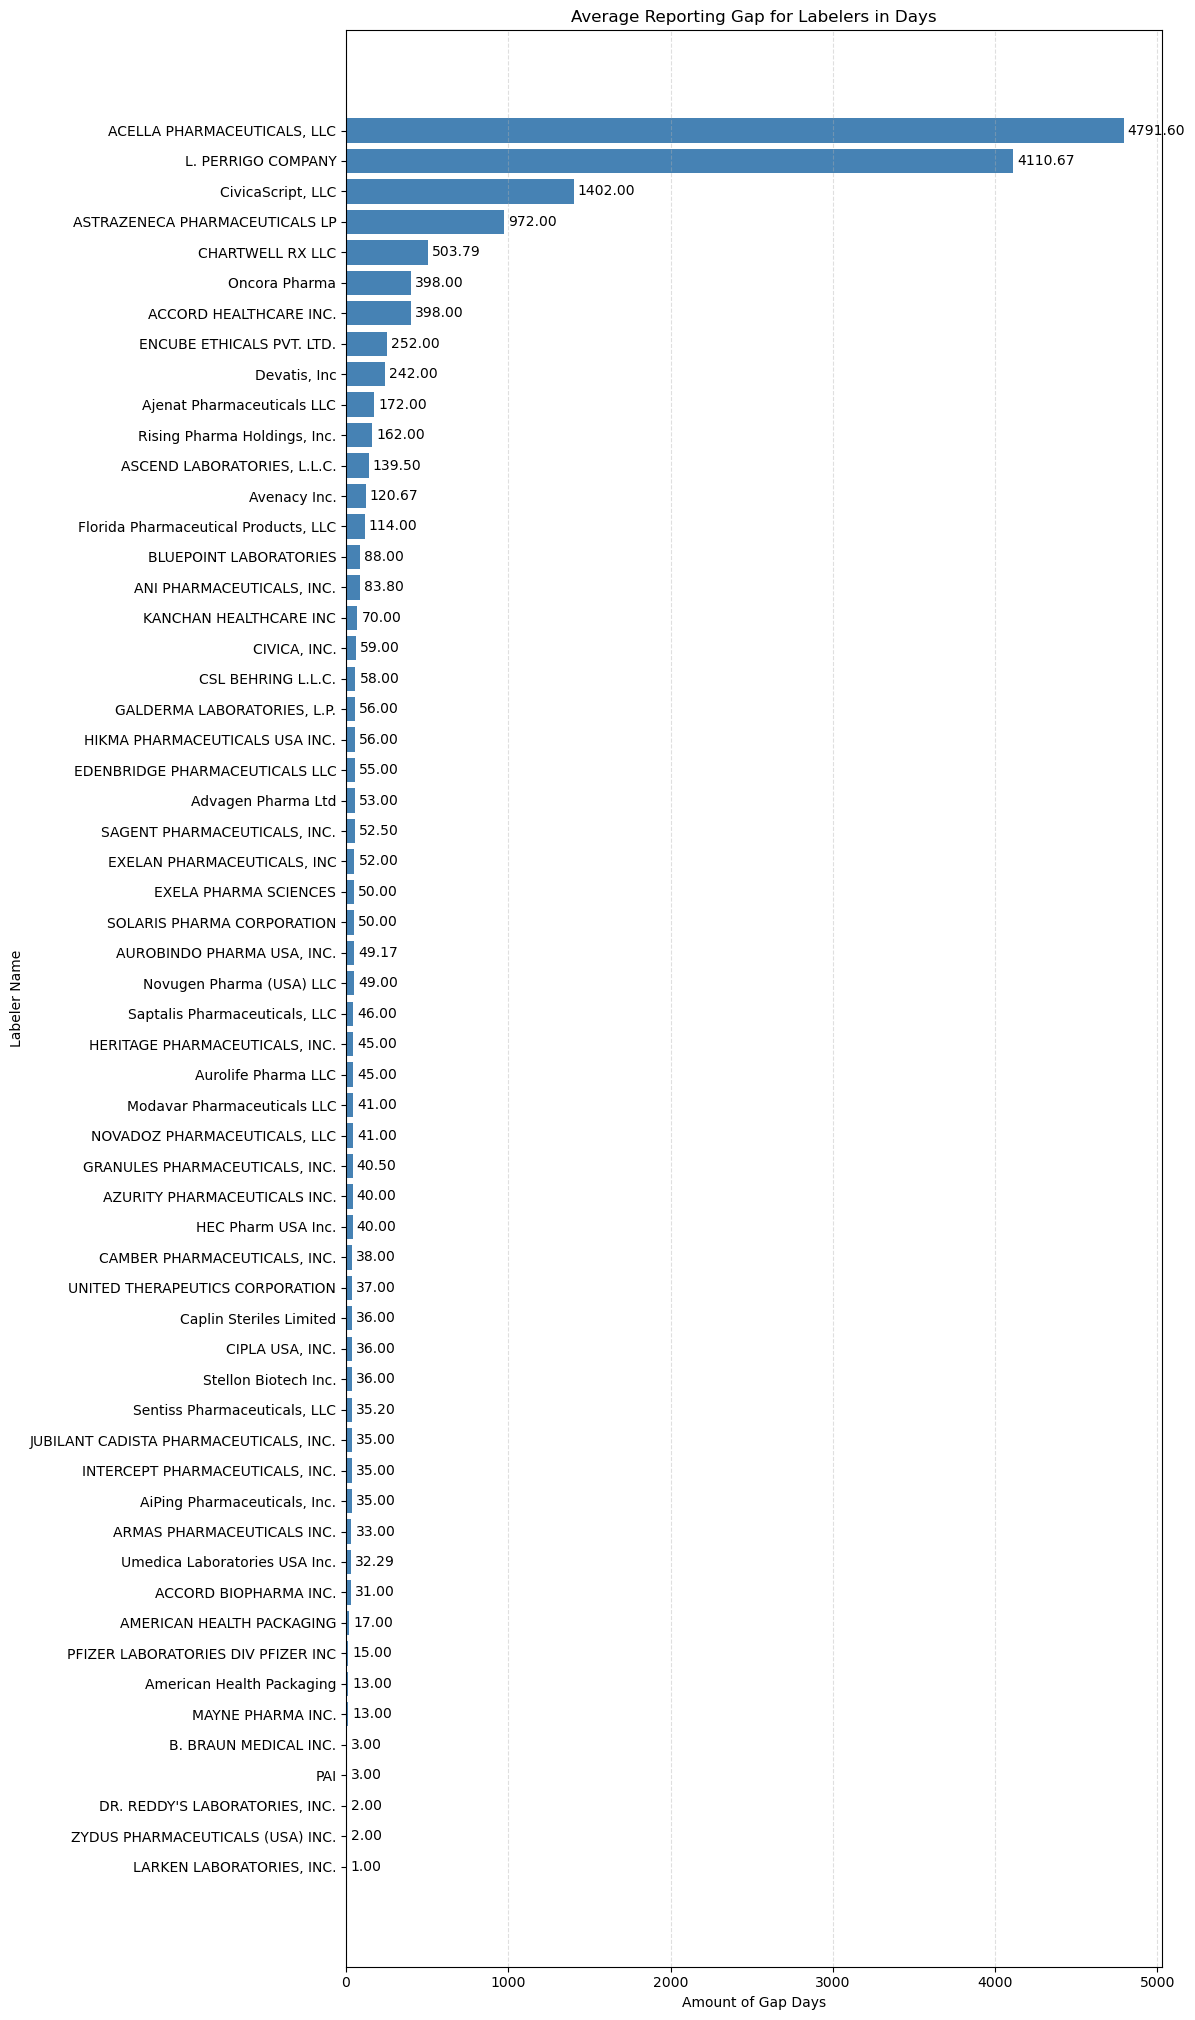

In [216]:
#print(gap_summary.sort_values("Average_Gap_Days",ascending=False))

gap_mean_labeler = unique_products.groupby("Labeler Name").agg(
    Average_Gap_Days = ("Reporting Gap Days","mean")).sort_values("Average_Gap_Days",ascending=True).reset_index()

fig, ax = plt.subplots(
    figsize=(12, max(8, len(gap_mean_labeler) * 0.35))
)

bars = ax.barh(
    gap_mean_labeler["Labeler Name"],
    gap_mean_labeler["Average_Gap_Days"],
    color="steelblue"
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value in gap_mean_labeler["Average_Gap_Days"]
    ],
    padding=3
)

ax.set_title("Average Reporting Gap for Labelers in Days")
ax.set_xlabel("Amount of Gap Days")
ax.set_ylabel("Labeler Name")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()



In [217]:
#gap_summary = (
    #unique_products.groupby("Labeler Name")
                   #.agg(
                       #Product_Count=("Reporting Gap Days", "count")
                   #)
                   #.sort_values("Product_Count", ascending=False)
                   #.reset_index()
#)

#gap_summary

In [218]:

drug_type_1 = (unique_products["Drug Type"] == 1).sum()
drug_type_2 = (unique_products["Drug Type"] == 2).sum()
total_idx = len(unique_products)

drug_type_1_portion = drug_type_1 / total_idx 
drug_type_2_portion = drug_type_2 / total_idx 

print(f"The proportion of the drugs that are prescription is {drug_type_1_portion:.2%} with {drug_type_1} submitted.")
print(f"The proportion of the drugs that are OTC is {drug_type_2_portion:.2%} with {drug_type_2} submitted.")

#unique_products["Drug Type"].value_counts(dropna=False)


The proportion of the drugs that are prescription is 90.51% with 143 submitted.
The proportion of the drugs that are OTC is 9.49% with 15 submitted.


### Analysis

+ Of the 158 total distinct ND9 products submitted, 90.51%(143) were prescription drugs. 9.49%(15) were over the counter drugs.
+ The number of prescription drugs significantly outnumber OTC drugs.
+ These figures only represent the composition of newly reported product listings.
+ Examining further reporting would clarify whether this significantly skewed proportion is typical or specific to only this time period. 

In [221]:
cod_status_eligible= (
    ~unique_products["COD Status"].isin([5,6])).sum()

print(unique_products["COD Status"].dtype)
print(unique_products["COD Status"].unique())
print(f"Number of products not coded 5 or 6: {cod_status_eligible}")


int64
[ 2  1 10  3 12  4  9]
Number of products not coded 5 or 6: 158


In [222]:
cod_status= (
    unique_products["COD Status"].value_counts(dropna=False).sort_index()
)
print(cod_status)

COD Status
1     135
2       3
3       6
4       2
9       1
10      6
12      5
Name: count, dtype: int64


### Visualization

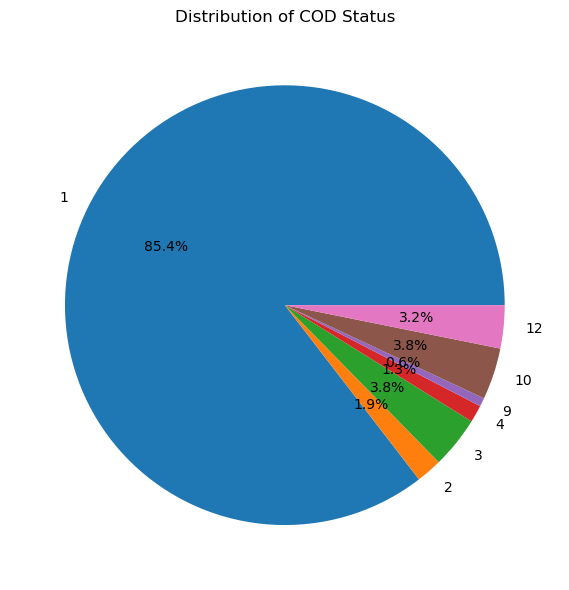

In [224]:
plt.figure(figsize=(8, 6))

plt.pie(
    cod_status.values,
    labels=cod_status.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of COD Status")
plt.tight_layout()
plt.show()


### Analysis

- The overwhelming majority of COD Status codes in this sample are 01, which are abbreviated new drug applications.
- The second most frequent codes are 3 and 10, which are new drug applications and final over-the-counter monograph drugs respectively.
- They are followed by code 12, which is an unapproved drug per 1927(k)(2)(A)(ii).
- The last three are biologics license application, NDA authorized generic, then lastly tentative over-the-counter monograph.
- In this week sample, there were no drugs under codes 5,6,7,8, or 11.
- This distribution is another candidate for metric tracking.

In [227]:
cod_status_summary = (
    unique_products["COD Status"]
    .value_counts(dropna=False)
    .rename_axis("COD Status")
    .reset_index(name="Product Count")
)

cod_status_summary["Percentage"] = (
    cod_status_summary["Product Count"]
    / len(unique_products)
    * 100
).round(2)

cod_status_summary = cod_status_summary.sort_values(
    "Product Count",
    ascending=False
).reset_index(drop=True)

print(cod_status_summary)

   COD Status  Product Count  Percentage
0           1            135       85.44
1          10              6        3.80
2           3              6        3.80
3          12              5        3.16
4           2              3        1.90
5           4              2        1.27
6           9              1        0.63


## Conclusion & Summary

This analysis examined newly reported drugs in the Medicaid Drug Rebate Program submitted by 58 distinct and unevenly represented labelers. The dataset contained 195 package configurations representing 158 unique products. Chartwell Rx LLC was the most represented labeler, with 14 packages corresponding to 14 products. Twenty-two labelers submitted only one package configuration, while 28 submitted only one unique product.

The five labelers reporting the most products accounted for 28.5% of all package configurations. This indicates that newly reported products and packages were concentrated among a relatively small group of labelers despite broad participation in the dataset. This concentration could become a useful monitoring metric when calculated across multiple weekly datasets. Large deviations from an established historical range could identify reporting periods that warrant further investigation, although they would not necessarily indicate reporting irregularities.

Thirty-three products had multiple package configurations, supporting the decision to distinguish NDC9 products from NDC11 packages. Avenacy Inc. had the largest number of packages associated with a single product: one NDC9 appeared in six NDC11 package configurations. No other labeler had more than two package configurations for an individual product. This demonstrates how package-level counts can overstate the number of distinct products when the NDC9 and NDC11 levels are not analyzed separately.

The therapeutic-equivalence-code distribution provided additional information about the products’ regulatory characteristics. AB was the most common code, accounting for 55.7% of unique products. An AB code indicates that actual or potential bioequivalence concerns have been resolved through adequate evidence. FDA considers approved drug products therapeutically equivalent when they are pharmaceutical equivalents, bioequivalence has been demonstrated, and they can be expected to have the same clinical effect and safety profile under the conditions specified in their labeling.

Pharmaceutical equivalents generally contain identical amounts of the same active ingredient in the same dosage form and route of administration and meet applicable standards for identity, strength, quality, and purity. Therapeutic equivalence applies only when comparing appropriate pharmaceutical equivalents; it does not mean that every AB-rated drug is interchangeable with every other AB-rated drug.

“Not Rated” was the second-largest therapeutic-equivalence category. This designation should not be interpreted as evidence that a product is unsafe, ineffective, or unable to meet bioequivalence standards. A product may lack a therapeutic-equivalence rating because there is no therapeutically equivalent multisource product against which FDA has assigned a rating or because an applicable evaluation is not represented in the Orange Book. AP was the third-largest category and generally represents injectable aqueous solutions and, in certain cases, intravenous nonaqueous solutions.

The most common dispensing units were tablets, milliliters, capsules, grams, each, and transdermal patches, respectively. Transdermal patches were the least common of these observed unit types. However, one weekly dataset is insufficient to determine whether this is a persistent pattern. Tracking unit-type distributions over time would show whether this ordering remains stable.

Approximately 22.15% of the newly reported products were classified as 5i drugs. This category consists of inhaled, infused, instilled, implanted, or injected drugs that are not generally dispensed through retail community pharmacies. Some may require administration by trained personnel or in specialized healthcare settings. The 5i classification is also relevant to how manufacturers calculate and report Average Manufacturer Price under the MDRP. 

The coverage-date analysis showed that the most frequent coverage-effective dates occurred during the month immediately preceding the dataset’s reporting week. Calculating the difference between the coverage-effective date and the CMS reporting date provides a measure of reporting latency. This metric could help determine whether products are typically reported shortly after their effective dates and whether those reporting patterns change over time. It should not, by itself, be interpreted as a measure of claims processing time, regulatory compliance, or rebate eligibility.

Prescription drugs accounted for 90.51% of the unique products, while over-the-counter products accounted for 9.49%. This distribution provides another useful baseline that can be compared across future reporting periods.

Covered Outpatient Drug status supplied additional information about how products qualify under the statutory COD definition. More than 85% of products had COD Status 01, indicating an Abbreviated New Drug Application. COD Status 03, representing New Drug Applications, and COD Status 10, representing final OTC monograph drugs, each accounted for 3.8%. Another 3.2% had COD Status 12, representing unapproved drugs that qualify under §1927(k)(2)(A)(ii). Here, “unapproved” does not automatically mean unlawfully marketed; the code identifies the statutory pathway through which the product meets the covered-outpatient-drug definition. COD Statuses 05 and 06, unlike the categories observed here, are specifically identified by CMS as ineligible for Medicaid coverage or rebates.

Taken together, this analysis establishes a repeatable framework for monitoring weekly MDRP reporting. It distinguishes products from package configurations, identifies the most active labelers, examines therapeutic-equivalence and COD classifications, describes product and dispensing characteristics, and measures the time between coverage-effective and reporting dates.

Because the dataset covers only one reporting week, its results should be treated as a snapshot rather than evidence of long-term industry behavior. Repeating the analysis across multiple weeks would make it possible to establish baseline distributions, measure variability, identify persistent trends, and flag unusually large departures for closer examination.